# Übung Histogramme

In [35]:
# package import
import numpy as np
import matplotlib.pyplot as plt
import cv2
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [36]:
# Bilddateien einladen
image = cv2.imread(r'images/crew.tif', cv2.IMREAD_GRAYSCALE)

#Datentyp:
imageDataType = image.dtype
#Bildgröße
imageShape = image.shape

# Ausgabe der Daten
print(f'Datentyp des Bildes: {imageDataType}')
print(f'Größe des Bildes: {imageShape}')

# Anzeige des Bildes
fig = px.imshow(image, color_continuous_scale='gray')
fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    width=500,
    height=500)
fig.show()

Datentyp des Bildes: uint8
Größe des Bildes: (269, 200)


## Histogramm

Das Histogramm eines Bildes gibt an wie viele Pixels eins Bildes einen bestimmten Grauwert besitzen. Das Histogramm wird in Bins unterteild, die die Grauwertintervalle angeben. Für ein 8bit Graustufenbild sind dies 256 Bins.

### Aufgabe:

Implementieren Sie die Funktion `myHist`, die aus einem 8bit Graustufenbild ein Histogramm berechnet.
* Verwenden Sie eine Klassengröße von 1, sodass das Histogramm die Werte in 2^8 bins unterteilt.

In [37]:
#----------------------------------
# Histogramm berechnen, Anzahl der Pixel in jedem bin zählen
#--------------------------------
def myHist(gray_image):
    #--------------------------------
    # 8 Bit-Quantisierung
    #--------------------------------
    b = 8

    #--------------------------------
    # Anzahl der Helligkeitsstufen
    #--------------------------------
    q = 2**b

    #--------------------------------
    # Histogramm initialisieren
    #--------------------------------
    # Es wird eine Liste mit q Nullen initialisiert
    histo = np.zeros(q)
    
    #--------------------------------
    # Histogrammwerte ermitteln
    #--------------------------------
    #######
    ## ENTER YOUR CODE HERE
    #######

    # Iteration über alle Pixel des Bildes
    for y in range(gray_image.shape[0]):
        for x in range(gray_image.shape[1]):
            # Zähle die Anzahl der Pixel für jeden Grauwert
            # Erhöhe den Wert im Histogramm an der Position des Grauwerts um 1
            histo[gray_image[y,x]] += 1

    return histo


Anzeigen von Histogramm und Bild

##### Aufgabe
Rufen Sie die Funktion `myHist` auf unsd speichern Sie das Ergebnis in der Variable `histo`. Dann wird das Histogramm und das Bild angezeigt.

Text(0, 0.5, 'Anzahl')

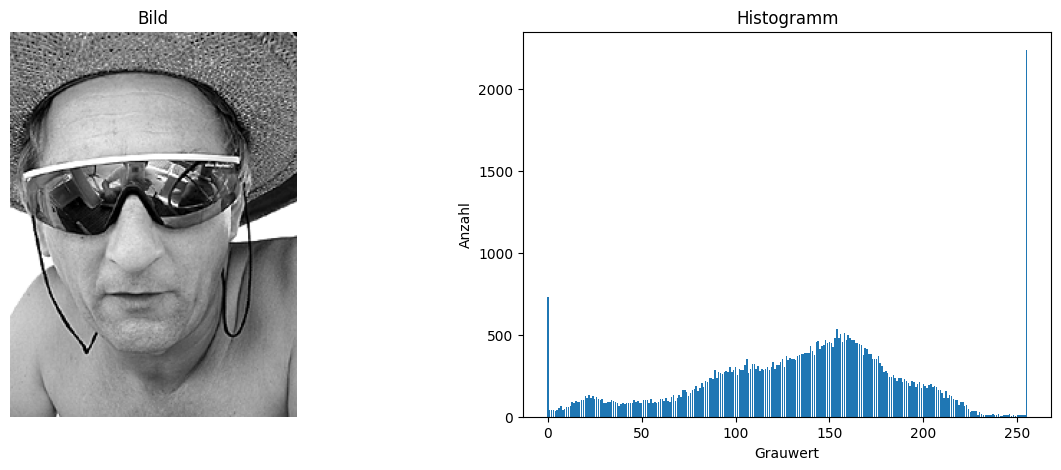

In [38]:
# Histogramm berechnen
histo = myHist(image)

# Bild und Histogramm anzeigen
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
# Bild anzeigen
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Bild')
axs[0].axis('off')

axs[1].bar(range(len(histo)), histo)
axs[1].set_title('Histogramm')
axs[1].set_xlabel('Grauwert')
axs[1].set_ylabel('Anzahl')

## Kummuliertes Histogramm

Ein kummuliertes Histogramm gibt an wie viele Pixel eines Bildes einen Grauwert kleiner oder gleich einem bestimmten Grauwert besitzen. Dieses lässt sich aus dem Histogramm berechnen indem die Werte nach und nach aufsummiert werden. 

### Aufgabe:

Implementieren Sie die Funktion `myCumHist`, die aus einem 8bit Graustufenbild das kummulierte Histogramm berechnet.Verwenden Sie hierzu die Funktion `myHist`.
Gehen Sie hierzu folgendermaßen vor:
* Berechnen Sie das Histogramm des Bildes mit der Funktion `myHist`.
* Initialisieren Sie ein leeres kummuliertes Histogramm `cum_histo`. Gleicher länge wie das Histogramm selbst 
* Iterieren Sie über alle Bins des Histogramms und summieren Sie die Werte auf. Tragen Sie die aufsummierten Wertde an die jeweilige Position im kummulierten Histogramm ein.

In [39]:
#--------------------------------
# Kumuliatives Histogramm
# Argument: Einkanaliges Bild
#--------------------------------
def myCumHist(gray_image):
    
    #--------------------------------
    # Histogramm
    #--------------------------------
    ######
    ## ENTER YOUR CODE HERE
    ######

    histo = myHist(gray_image)
    
    #--------------------------------
    # Initialisieren
    #--------------------------------
    cum_histo  = np.zeros(histo.shape[0])
    sum = 0
    #--------------------------------
    # Aufsummieren
    #--------------------------------
    for i in range(cum_histo.shape[0]):
        sum += histo[i]
        cum_histo[i] = sum
    
    return cum_histo

#### Anzeigen der Histogramme

In [40]:
# Funktionsdefinition für ein vereinfachtes Anzeigen von Bild, Histogramm und kumuliertem Histogramm

def displayImageAndAllHist(image):

    histo = myHist(image)
    cumHisto = myCumHist(image)
    
    # Matplotlib Plot mit Bild und Histogramm
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Bild anzeigen
    axs[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title('Bild')
    axs[0].axis('off')

    # Histogramm
    axs[1].bar(range(len(histo)), histo)
    axs[1].set_title('Histogramm')
    axs[1].set_xlabel('Grauwert')
    axs[1].set_ylabel('Anzahl')

    # Kumuliertes Histogramm
    axs[2].plot(range(len(cumHisto)), cumHisto, color='red')
    axs[2].set_title('Kumuliertes Histogramm')
    axs[2].set_xlabel('Grauwert')
    axs[2].set_ylabel('Kumuliert')

    plt.tight_layout()
    plt.show()

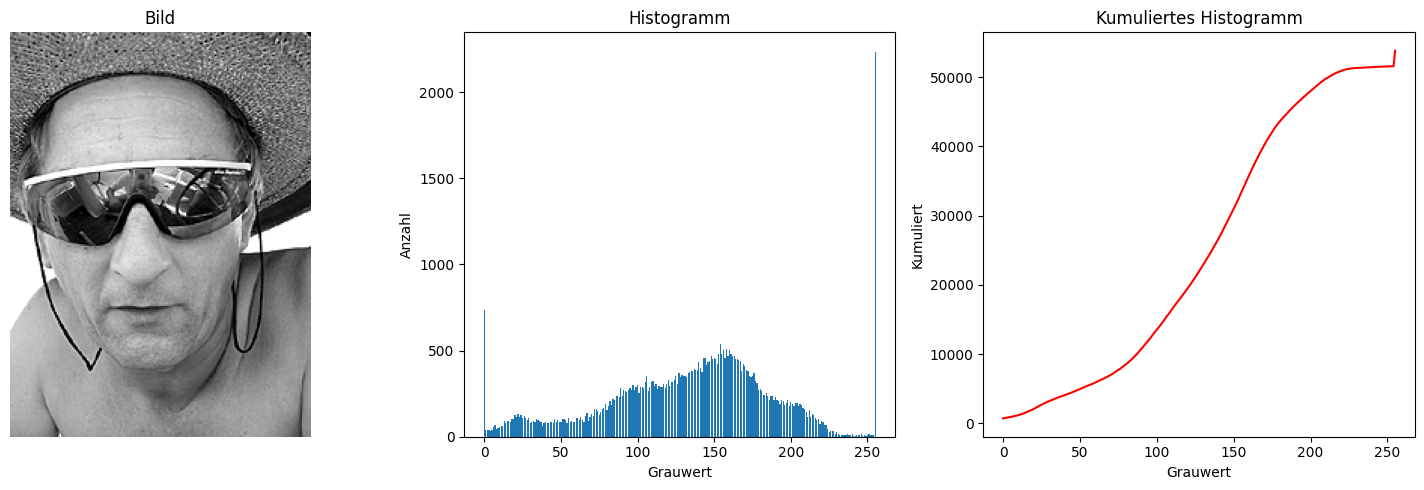

In [41]:
# anzeigen von Bild und Histogrammen
displayImageAndAllHist(image)

### Einige Histogramme 

#### Aufgabe:
schauen Sie sich die Histogramme der folgenden Bilder an und überlegen Sie wieso diese so aussehen

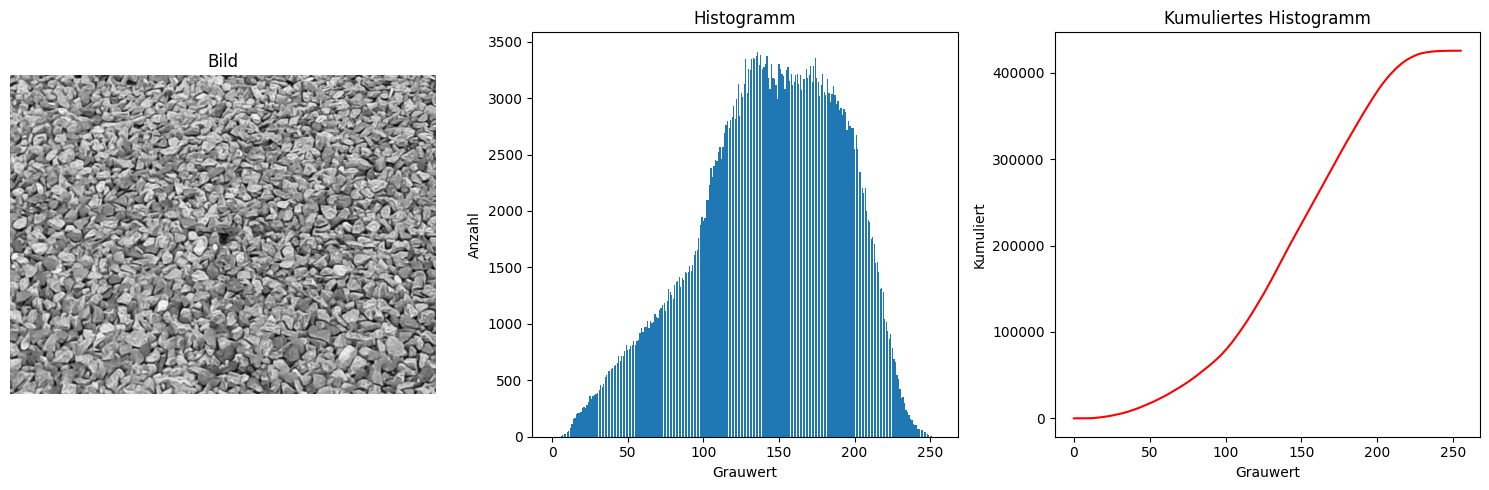

In [42]:
img_stones3 = cv2.imread(r'images/stones3.jpg', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_stones3)

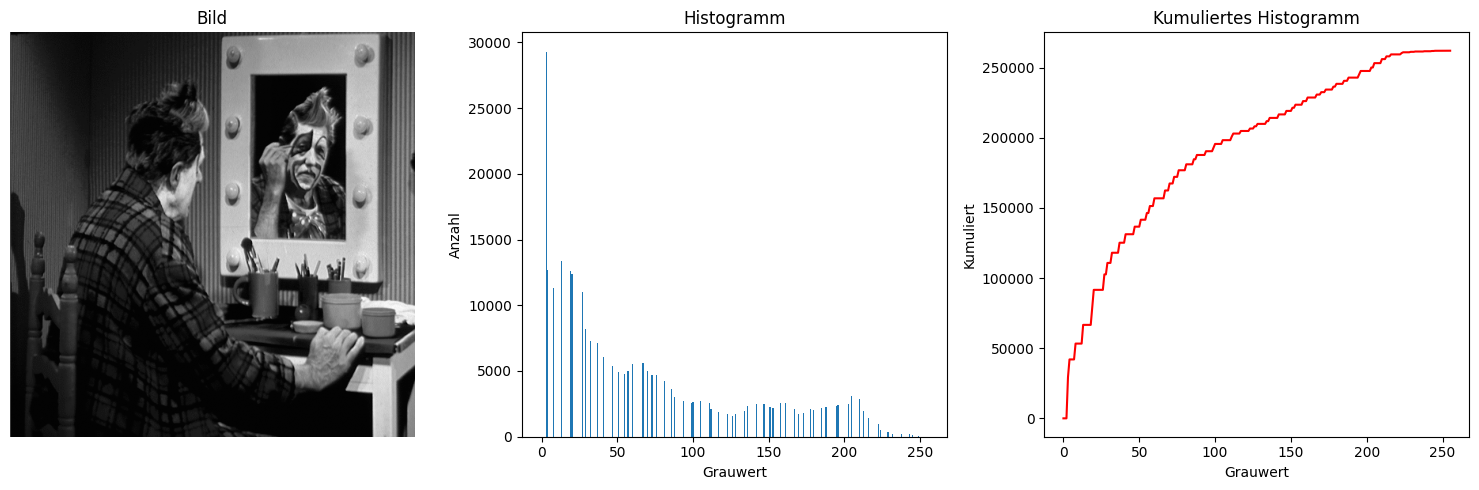

In [43]:
img_clown = cv2.imread(r'images/clown.bmp', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_clown)

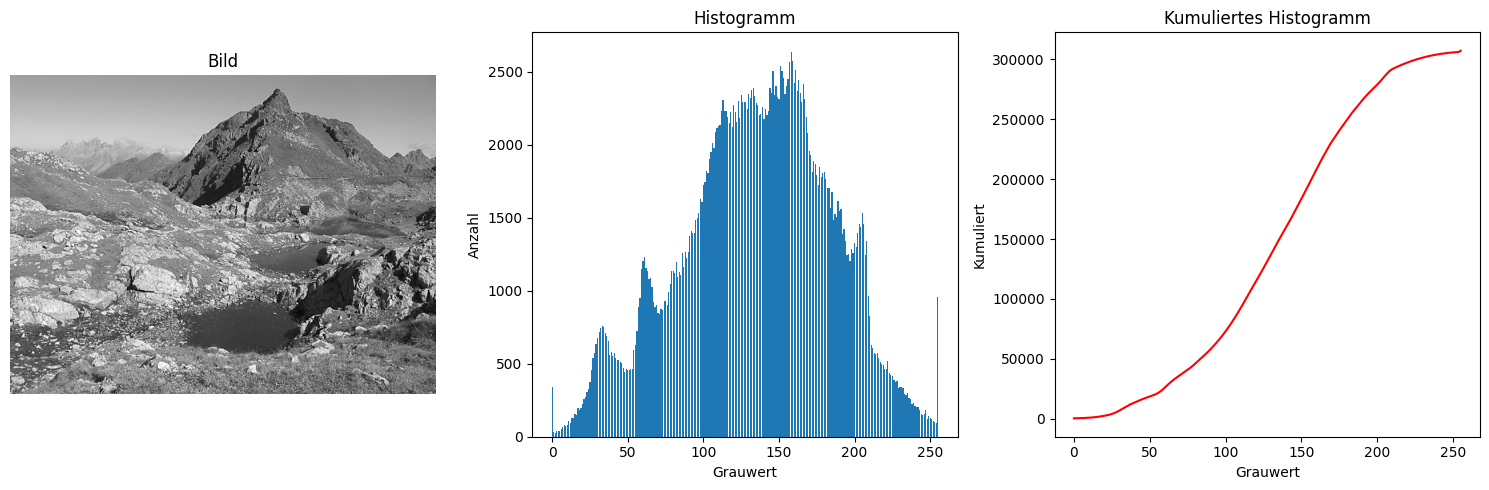

In [44]:
img_alps = cv2.imread(r'images/alps.tif', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_alps)

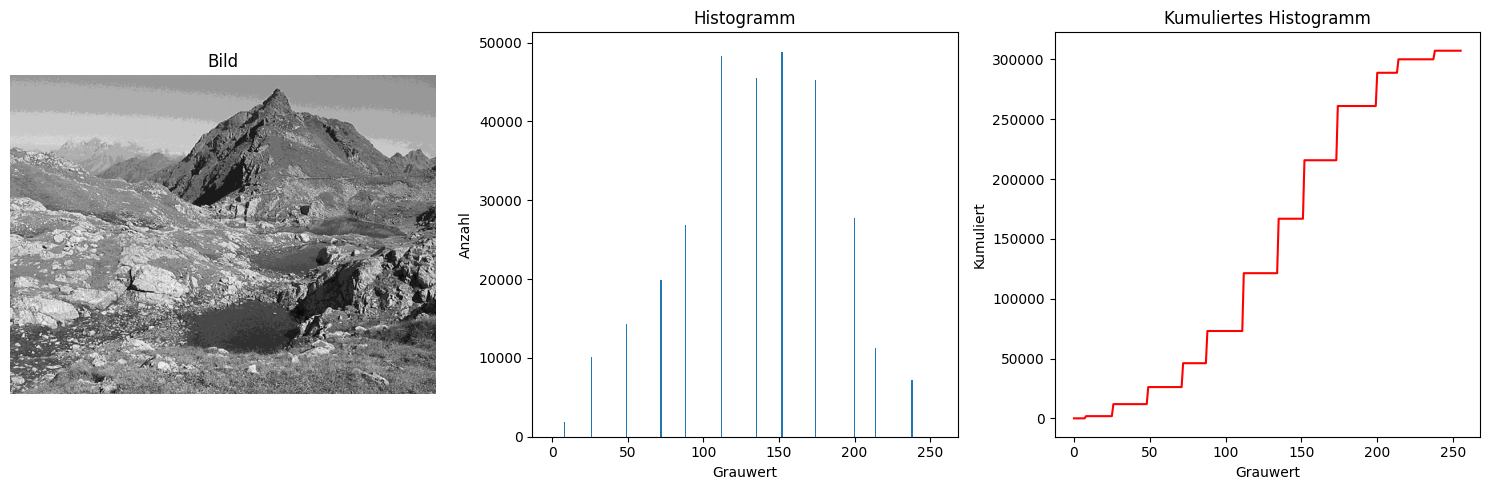

In [45]:
img_alps2 = cv2.imread(r'images/alps_comp.tif', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_alps2)

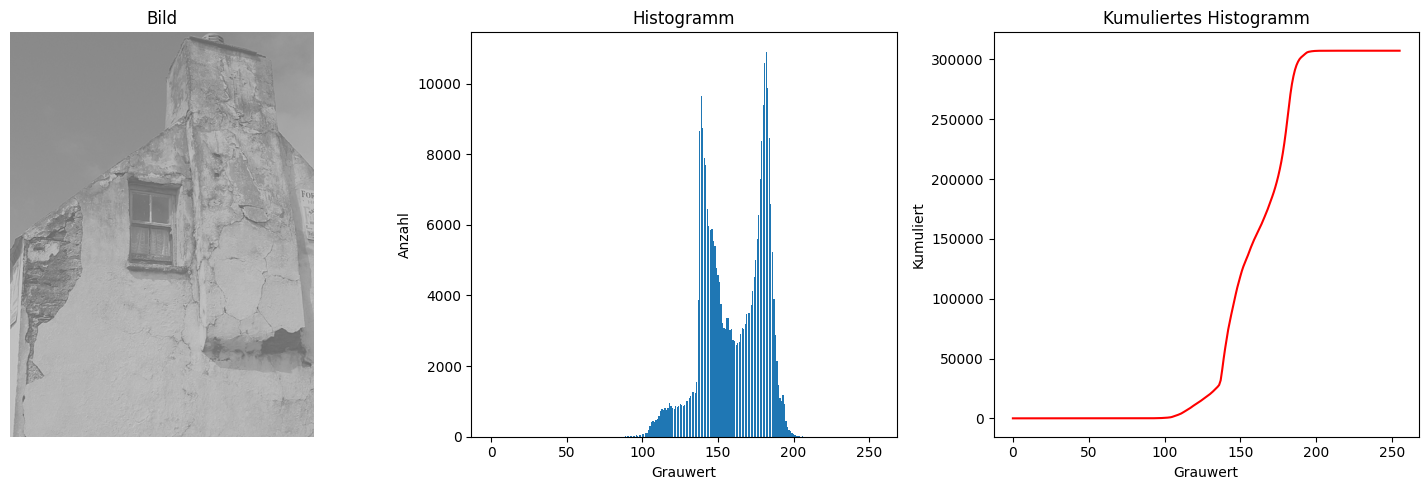

In [46]:
img_ireland = cv2.imread(r'images/ireland.tif', cv2.IMREAD_GRAYSCALE)
displayImageAndAllHist(img_ireland)